In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/House Price Prediction Dataset.csv')
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


### Exploratory Data Analysis (EDA) ###

1. Price Distribution:


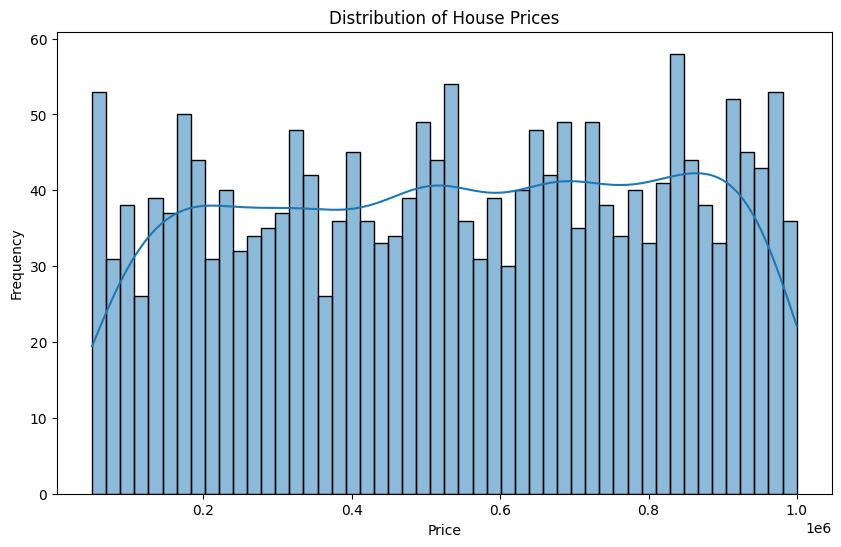


2. Missing Values:
No missing values found in the dataset.

3. Outliers in Price:


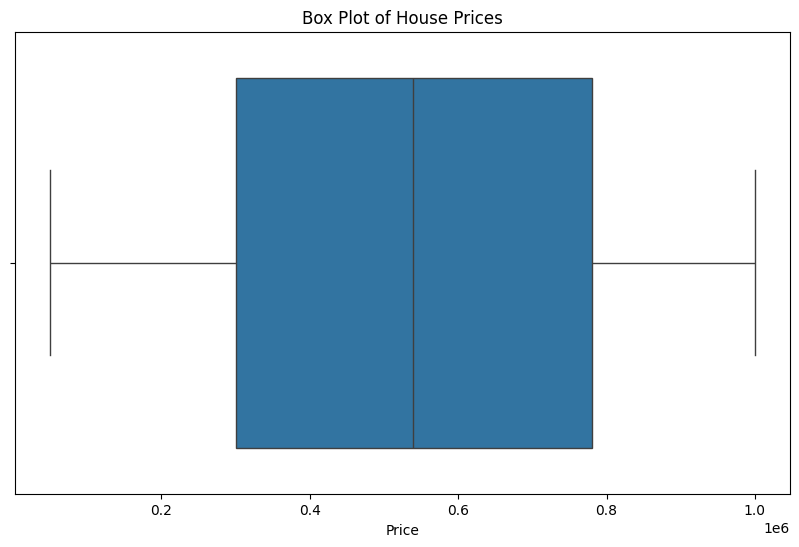

Number of outliers in 'Price' using IQR method: 0

4. Feature Relationships with Price:

  a. Numerical Features vs. Price (Scatter Plots):


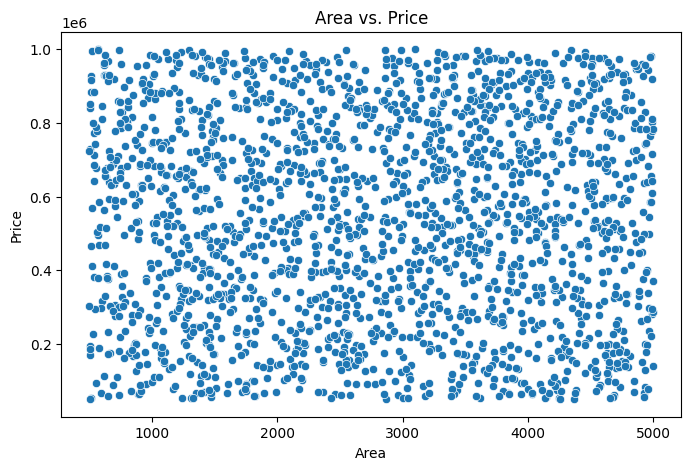

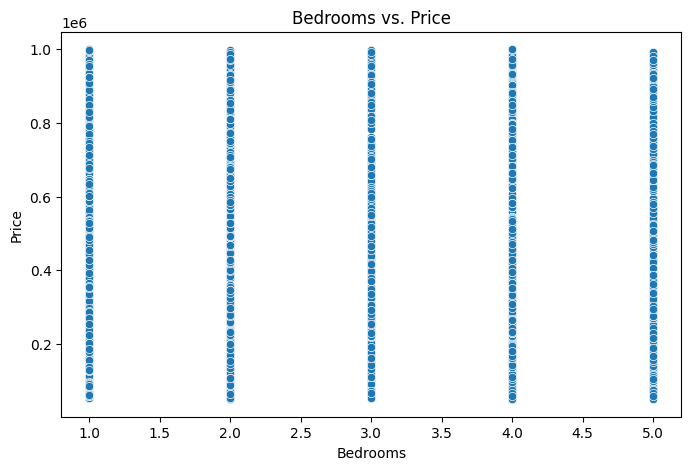

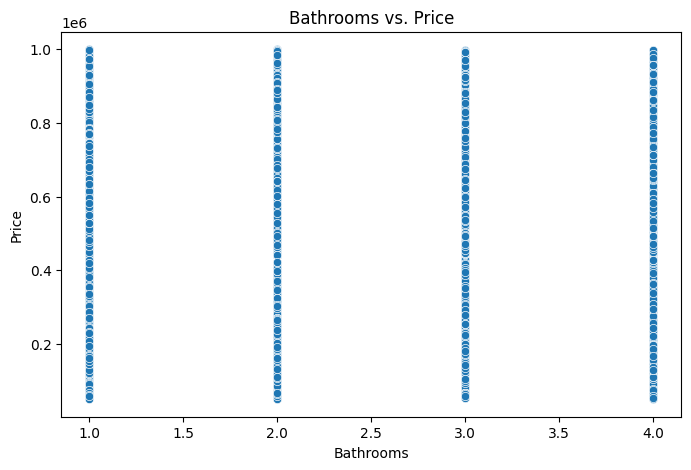

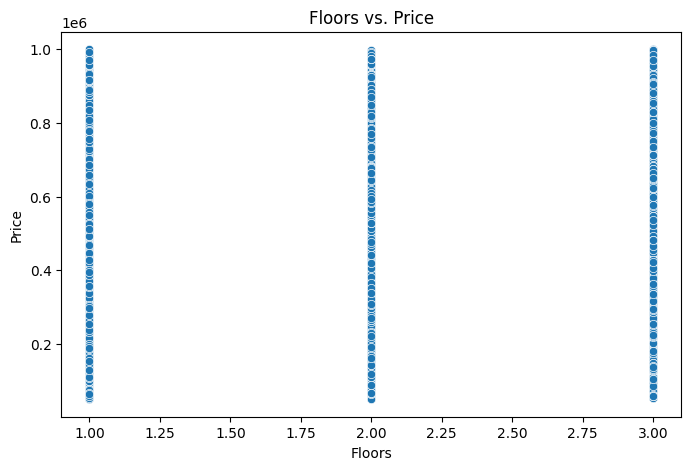

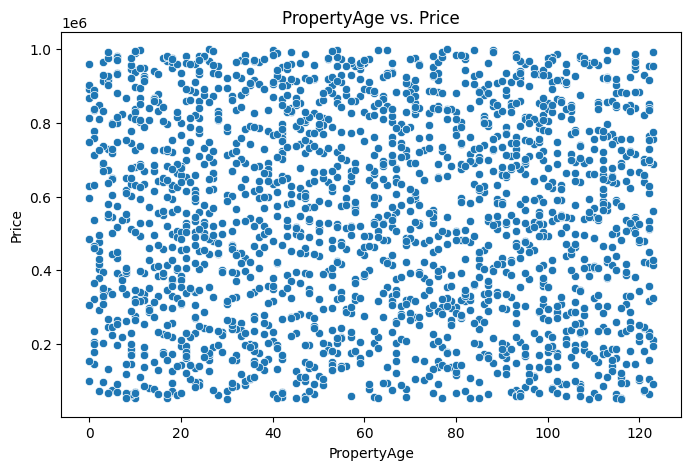


  b. Correlation Matrix of Numerical Features and Price:


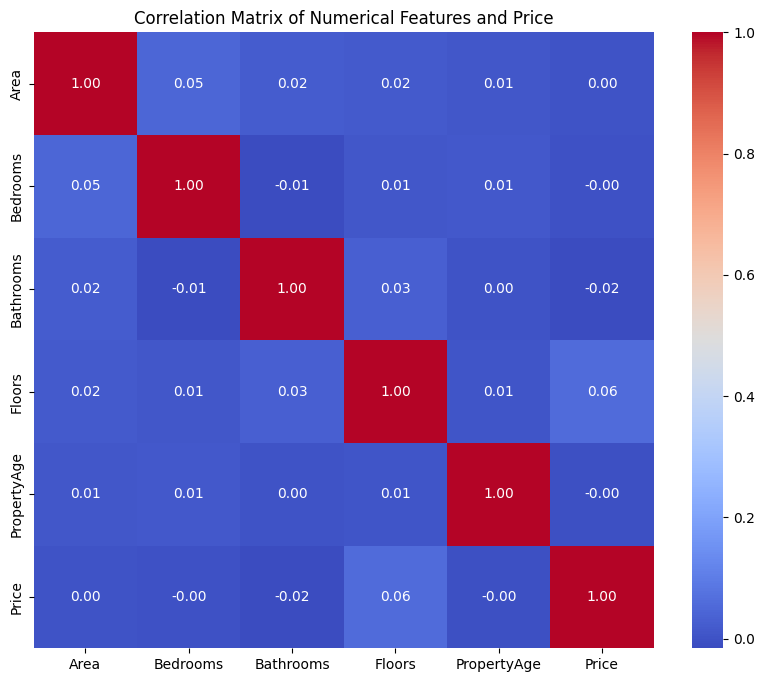


  c. Categorical Features vs. Price (Box Plots):


In [28]:
print("### Exploratory Data Analysis (EDA) ###")

# 1. Price Distribution
print("\n1. Price Distribution:")
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, bins=50)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# 2. Missing Values
print("\n2. Missing Values:")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if missing_values.empty:
    print("No missing values found in the dataset.")
else:
    print(missing_values)

# 3. Outliers (Focus on 'Price')
print("\n3. Outliers in Price:")
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Price'])
plt.title('Box Plot of House Prices')
plt.xlabel('Price')
plt.show()

# Using IQR to identify numerical outliers
Q1_price = df['Price'].quantile(0.25)
Q3_price = df['Price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

outliers_price = df[(df['Price'] < lower_bound_price) | (df['Price'] > upper_bound_price)]
print(f"Number of outliers in 'Price' using IQR method: {len(outliers_price)}")
if not outliers_price.empty:
    print(f"Lower bound for outliers: {lower_bound_price:.2f}")
    print(f"Upper bound for outliers: {upper_bound_price:.2f}")

# 4. Feature Relationships with Price
print("\n4. Feature Relationships with Price:")

# Numerical Features vs. Price
numerical_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'PropertyAge'] # Assuming PropertyAge exists or will be created

# If 'PropertyAge' is not directly in df but is in kernel state, calculate it here if needed
if 'PropertyAge' not in df.columns and 'YearBuilt' in df.columns:
    current_year = 2023 # As seen in kernel state
    df['PropertyAge'] = current_year - df['YearBuilt']
    numerical_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'PropertyAge'] # Update numerical features list

print("\n  a. Numerical Features vs. Price (Scatter Plots):")
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df[feature], y=df['Price'])
    plt.title(f'{feature} vs. Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.show()

print("\n  b. Correlation Matrix of Numerical Features and Price:")
correlation_matrix = df[numerical_features + ['Price']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features and Price')
plt.show()

# Categorical Features vs. Price
categorical_features = ['Location', 'Condition', 'Garage']

print("\n  c. Categorical Features vs. Price (Box Plots):")
for feature in categorical_features:
    if feature in df.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=df[feature], y=df['Price'])
        plt.title(f'{feature} vs. Price')
        plt.xlabel(feature)
        plt.ylabel('Price')
        plt.xticks(rotation=45)
        plt.show()
    else:
        print(f"Warning: Categorical feature '{feature}' not found in DataFrame.")


In [30]:
print("### Data Cleaning ###")

# Make a copy of the DataFrame to perform cleaning operations
df_cleaned = df.copy()
initial_rows = len(df_cleaned)

print(f"\nInitial number of rows: {initial_rows}")

# 1. Handle missing values
print("\n1. Handling Missing Values:")
# Updated numerical_cols to include 'PropertyAge' and remove 'YearBuilt'
numerical_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'PropertyAge', 'Price']
categorical_cols = ['Location', 'Condition', 'Garage']

for col in numerical_cols:
    if col in df_cleaned.columns and df_cleaned[col].isnull().any():
        median_val = df_cleaned[col].median()
        df_cleaned[col].fillna(median_val, inplace=True)
        print(f"  Filled missing values in numerical column '{col}' with median: {median_val}")

for col in categorical_cols:
    if col in df_cleaned.columns and df_cleaned[col].isnull().any():
        mode_val = df_cleaned[col].mode()[0] # .mode() can return multiple values, take the first
        df_cleaned[col].fillna(mode_val, inplace=True)
        print(f"  Filled missing values in categorical column '{col}' with mode: {mode_val}")

print(f"Missing values after imputation:\n{df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0]}")

# 2. Remove duplicates
print("\n2. Removing Duplicates:")
df_cleaned.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - len(df_cleaned)
print(f"  Removed {duplicates_removed} duplicate rows.")

# Update initial_rows for subsequent calculations
initial_rows = len(df_cleaned)

# 3. Fix incorrect values (Placeholder - specific issues are not yet identified)
print("\n3. Fixing Incorrect Values: (No specific issues identified for correction at this stage)")
# Example: Ensure 'YearBuilt' is within a reasonable range or convert data types if needed.
# For now, we assume data types are correct from pd.read_csv and no obvious incorrect values without specific instructions.

# 4. Remove extreme outliers (luxury anomalies)
print("\n4. Removing Extreme Outliers (Luxury Anomalies):")
# Focusing on 'Price' and 'Area' as potential indicators of luxury anomalies

def remove_extreme_outliers(df, column, multiplier=3.0):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    initial_count = len(df)
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    outliers_count = initial_count - len(df_filtered)
    print(f"  Removed {outliers_count} extreme outliers from '{column}' (using {multiplier}*IQR).")
    return df_filtered, outliers_count

# Apply outlier removal to 'Price'
df_cleaned, outliers_price_removed = remove_extreme_outliers(df_cleaned, 'Price', multiplier=3.0)

# Apply outlier removal to 'Area'
df_cleaned, outliers_area_removed = remove_extreme_outliers(df_cleaned, 'Area', multiplier=3.0)

total_outliers_removed = outliers_price_removed + outliers_area_removed # This might double count if same row is outlier in both

# Recalculate total rows after all cleaning steps
final_rows = len(df_cleaned)
total_removed = len(df) - final_rows

print(f"\nSummary of Cleaning:")
print(f"  Initial rows: {len(df)}")
print(f"  Final rows after cleaning: {final_rows}")
print(f"  Total rows removed during cleaning: {total_removed}")
print("Data cleaning complete. The cleaned DataFrame is now available as `df_cleaned`.")

# Display basic info of the cleaned dataframe
print("\nCleaned DataFrame Info:")
df_cleaned.info()


### Data Cleaning ###

Initial number of rows: 2000

1. Handling Missing Values:
Missing values after imputation:
Series([], dtype: int64)

2. Removing Duplicates:
  Removed 0 duplicate rows.

3. Fixing Incorrect Values: (No specific issues identified for correction at this stage)

4. Removing Extreme Outliers (Luxury Anomalies):
  Removed 0 extreme outliers from 'Price' (using 3.0*IQR).
  Removed 0 extreme outliers from 'Area' (using 3.0*IQR).

Summary of Cleaning:
  Initial rows: 2000
  Final rows after cleaning: 2000
  Total rows removed during cleaning: 0
Data cleaning complete. The cleaned DataFrame is now available as `df_cleaned`.

Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Area               2000 non-null   int64
 1   Bedrooms           2000 non-null   int64
 2   Bathrooms          2000 non-null 

### Data Visualization on Cleaned Data ###

1. Distribution of Price (Cleaned Data):


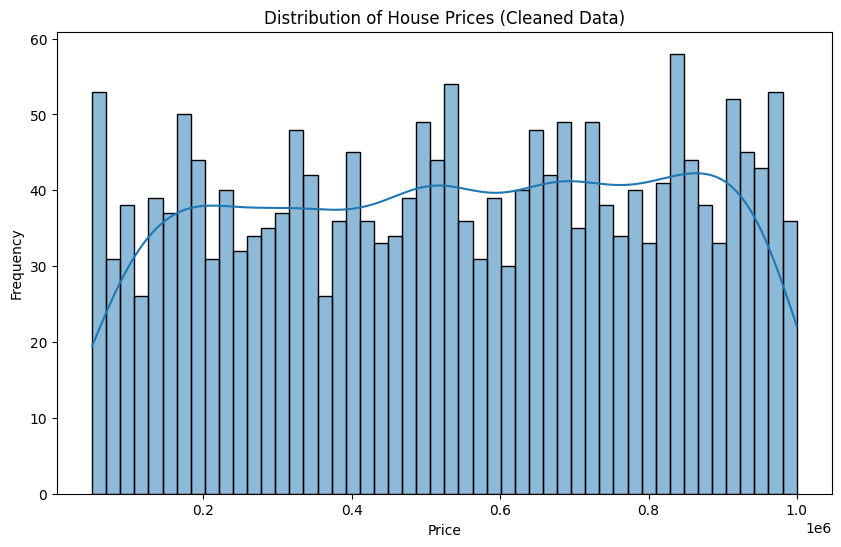


2. Numerical Features vs. Price (Cleaned Data):


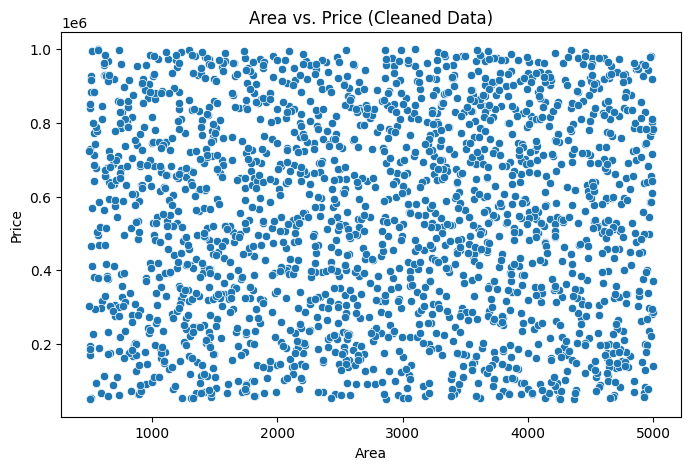

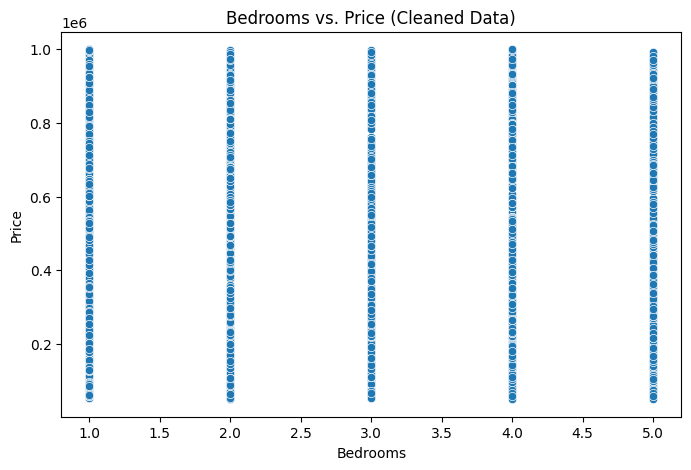

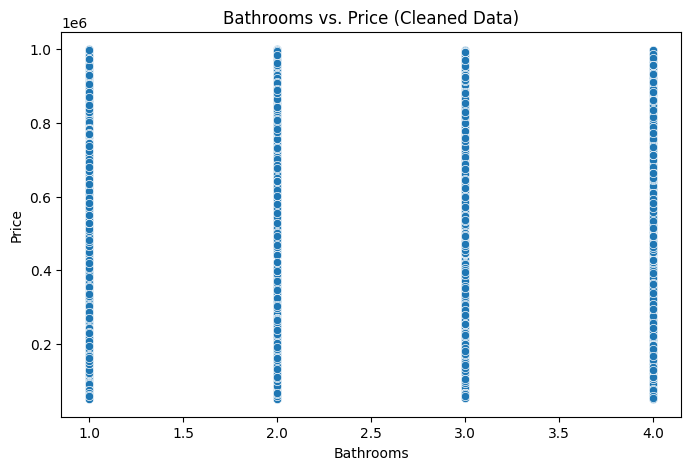

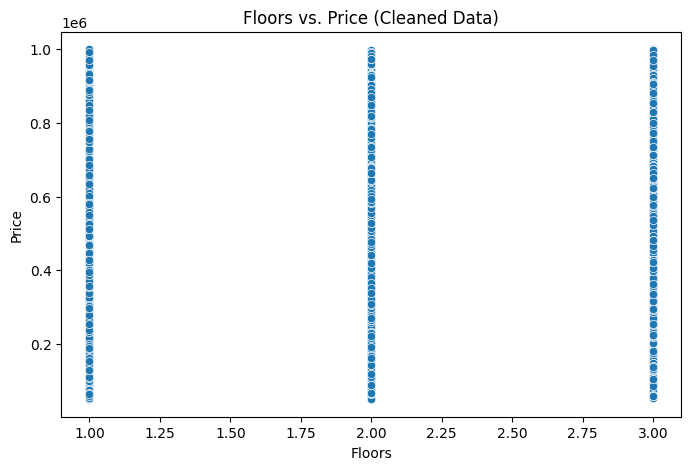

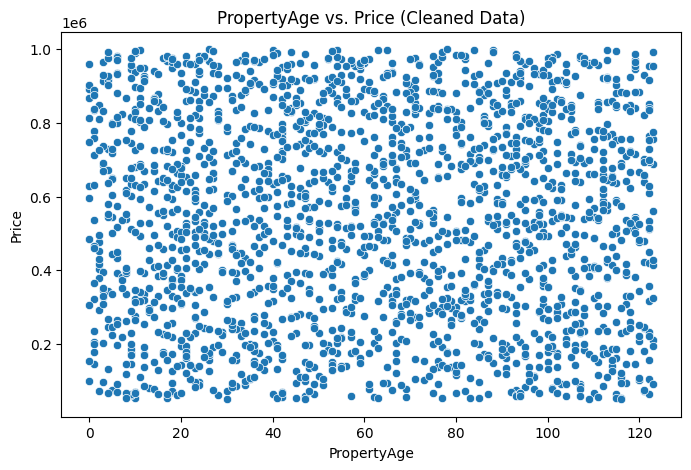

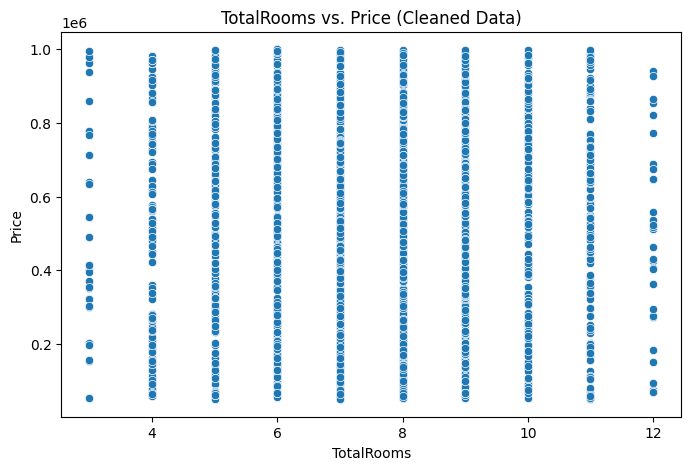


3. Correlation Matrix of Numerical Features and Price (Cleaned Data):


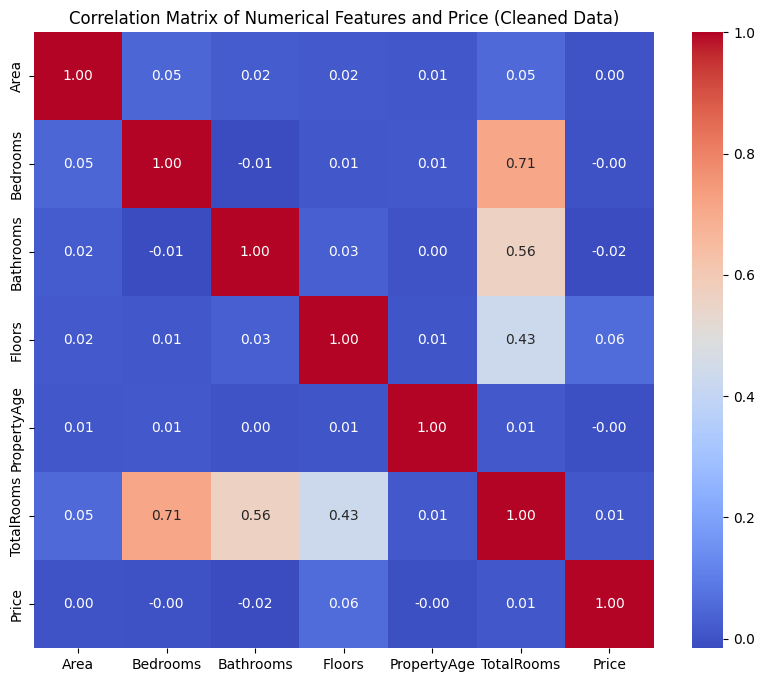


4. Categorical Features vs. Price (Cleaned Data):


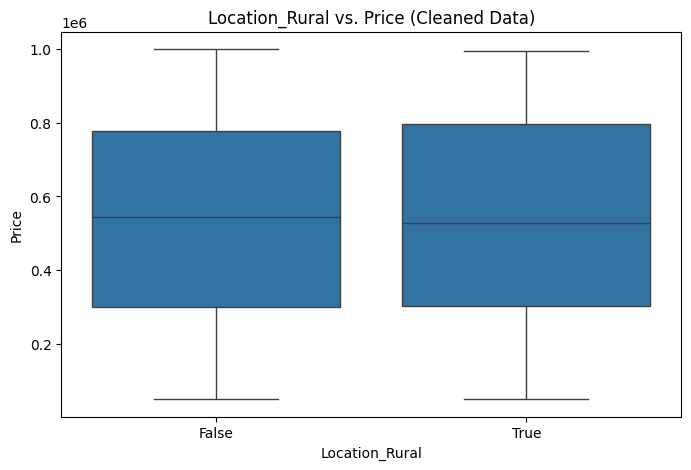

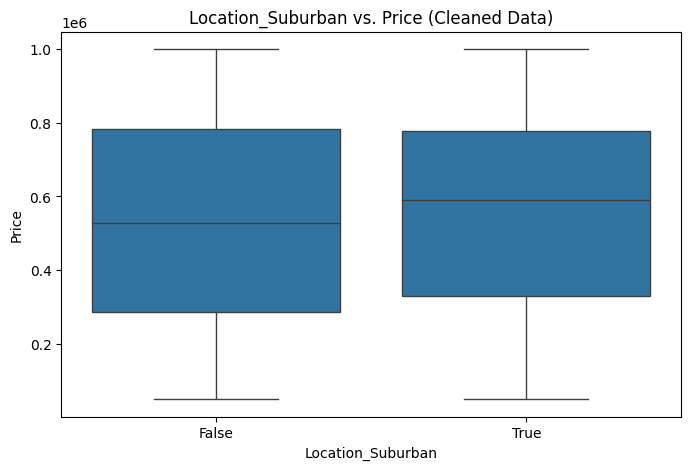

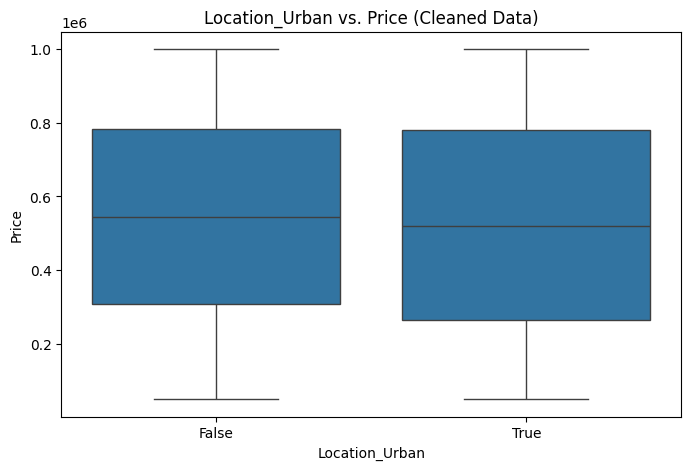

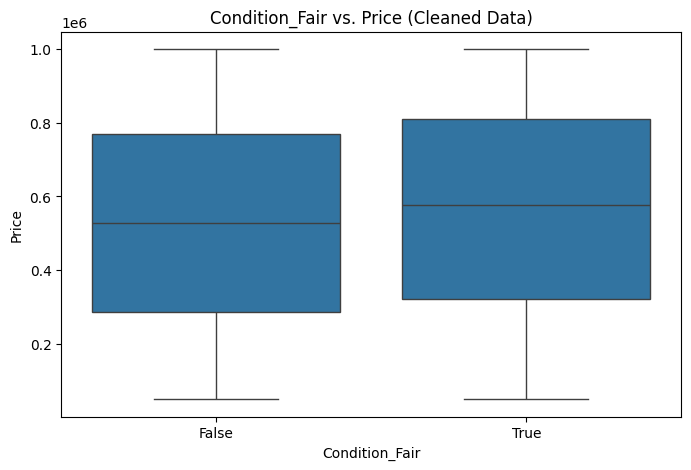

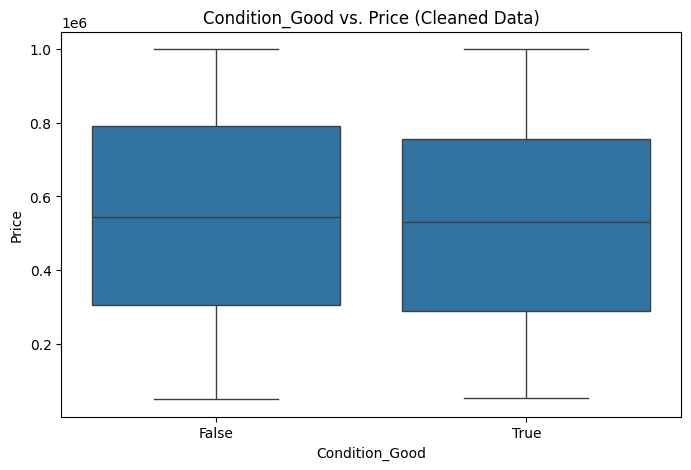

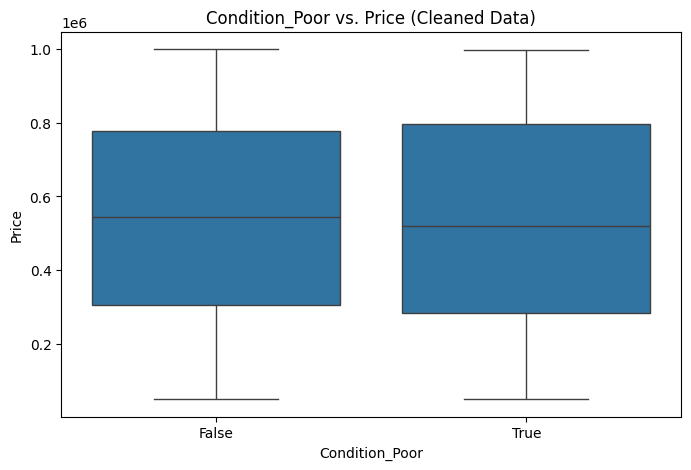

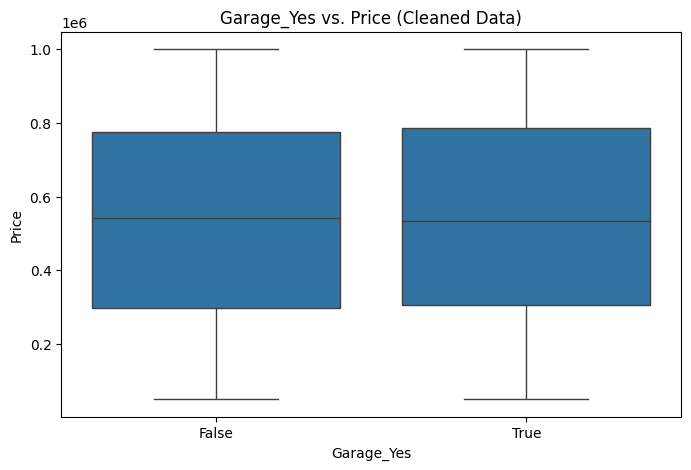

In [31]:
print("### Data Visualization on Cleaned Data ###")

# 1. Price Distribution after Cleaning
print("\n1. Distribution of Price (Cleaned Data):")
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Price'], kde=True, bins=50)
plt.title('Distribution of House Prices (Cleaned Data)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# 2. Relationships of Numerical Features with Price (Cleaned Data)
numerical_features_cleaned = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'PropertyAge', 'TotalRooms']

print("\n2. Numerical Features vs. Price (Cleaned Data):")
for feature in numerical_features_cleaned:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df_cleaned[feature], y=df_cleaned['Price'])
    plt.title(f'{feature} vs. Price (Cleaned Data)')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.show()

# 3. Correlation Matrix of Numerical Features and Price (Cleaned Data)
print("\n3. Correlation Matrix of Numerical Features and Price (Cleaned Data):")
correlation_matrix_cleaned = df_cleaned[numerical_features_cleaned + ['Price']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_cleaned, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features and Price (Cleaned Data)')
plt.show()

# 4. Relationships of Categorical Features with Price (Cleaned Data)
# Using the one-hot encoded columns from df_cleaned
categorical_features_cleaned_ohe = [
    'Location_Rural', 'Location_Suburban', 'Location_Urban',
    'Condition_Fair', 'Condition_Good', 'Condition_Poor',
    'Garage_Yes'
]

print("\n4. Categorical Features vs. Price (Cleaned Data):")
for feature in categorical_features_cleaned_ohe:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df_cleaned[feature], y=df_cleaned['Price'])
    plt.title(f'{feature} vs. Price (Cleaned Data)')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.show()


### Data Transformation ###

1. Log Transforming 'Price'...
  'Price' column has been log-transformed to 'y_log'.


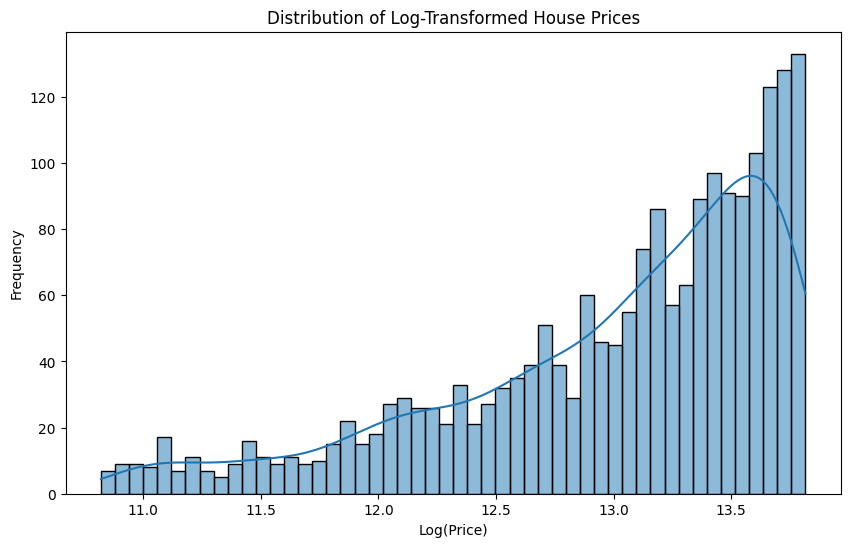


2. Normalizing / Scaling Features...
  Numerical features have been scaled using StandardScaler.
  The transformed feature set is available as `X_scaled`.

Shape of X_scaled: (2000, 13)
First 5 rows of X_scaled:
        Area  Bedrooms  Bathrooms    Floors  PropertyAge  TotalRooms  \
0 -1.101471  1.401791   1.305568  1.244151    -0.238155    2.239134   
1  1.147485  1.401791   1.305568  1.244151     0.095942    2.239134   
2  0.622317 -0.704581  -0.498326  1.244151     0.652770   -0.276464   
3 -1.405759  0.699667  -0.498326  0.008035     1.655061    0.226655   
4  1.652574 -1.406705   1.305568  0.008035    -0.377363   -0.276464   

   Location_Rural  Location_Suburban  Location_Urban  Condition_Fair  \
0           False              False           False           False   
1           False              False           False           False   
2           False              False           False           False   
3           False               True           False            True   

In [32]:
print("### Data Transformation ###")

# 1. Log Transform Target Variable (Price)
print("\n1. Log Transforming 'Price'...")
y_log = np.log1p(df_cleaned['Price'])
print("  'Price' column has been log-transformed to 'y_log'.")

# Visualize the log-transformed price distribution
plt.figure(figsize=(10, 6))
sns.histplot(y_log, kde=True, bins=50)
plt.title('Distribution of Log-Transformed House Prices')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.show()

# 2. Normalize / Scale Features
print("\n2. Normalizing / Scaling Features...")
from sklearn.preprocessing import StandardScaler

# Separate features (X) from the original target (Price) in the cleaned DataFrame
X = df_cleaned.drop('Price', axis=1)

# Identify numerical and one-hot encoded categorical features in X
numerical_features_to_scale = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'PropertyAge', 'TotalRooms']
# Ensure 'TotalRooms' is present or create it if needed
if 'TotalRooms' not in X.columns:
    X['TotalRooms'] = X['Bedrooms'] + X['Bathrooms'] # Example, assuming this was intended

# Re-check numerical_features_to_scale based on existing columns in X
numerical_features_to_scale = [col for col in numerical_features_to_scale if col in X.columns]

categorical_features_ohe = [
    'Location_Rural', 'Location_Suburban', 'Location_Urban',
    'Condition_Fair', 'Condition_Good', 'Condition_Poor',
    'Garage_Yes'
]
# Filter for columns that actually exist in X (important for robustness)
categorical_features_ohe = [col for col in categorical_features_ohe if col in X.columns]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features
X_scaled_numerical = scaler.fit_transform(X[numerical_features_to_scale])
X_scaled_numerical_df = pd.DataFrame(X_scaled_numerical, columns=numerical_features_to_scale, index=X.index)

# Combine scaled numerical features with one-hot encoded categorical features
X_scaled = pd.concat([X_scaled_numerical_df, X[categorical_features_ohe]], axis=1)

print("  Numerical features have been scaled using StandardScaler.")
print("  The transformed feature set is available as `X_scaled`.")
print("\nShape of X_scaled:", X_scaled.shape)
print("First 5 rows of X_scaled:\n", X_scaled.head())


In [33]:
print("### Feature Engineering ###")

# We will work on a copy of df_cleaned to add new features
df_fe = df_cleaned.copy()

# 1. Price per sq ft
print("\n1. Creating 'Price_per_sq_ft'...")
# Handle cases where 'Area' might be zero to avoid division by zero
df_fe['Price_per_sq_ft'] = df_fe.apply(lambda row: row['Price'] / row['Area'] if row['Area'] != 0 else 0, axis=1)
print("  'Price_per_sq_ft' created. (Price / Area)")

# 2. House age
print("\n2. 'House Age' (PropertyAge):")
if 'PropertyAge' in df_fe.columns:
    print("  'PropertyAge' (House Age) is already present in the dataset.")
else:
    # This block should ideally not run if previous EDA/Cleaning steps were executed
    print("  'PropertyAge' not found. Re-calculating as current_year (2023) - YearBuilt...")
    current_year = 2023 # Assuming current year is 2023 based on previous context
    df_fe['PropertyAge'] = current_year - df_fe['YearBuilt']

# 3. Total rooms
print("\n3. 'Total Rooms':")
if 'TotalRooms' in df_fe.columns:
    print("  'TotalRooms' (Bedrooms + Bathrooms) is already present in the dataset.")
else:
    # This block should ideally not run if previous EDA/Cleaning steps were executed
    print("  'TotalRooms' not found. Re-calculating as Bedrooms + Bathrooms...")
    df_fe['TotalRooms'] = df_fe['Bedrooms'] + df_fe['Bathrooms']

# Advanced Features - Discussion on feasibility
print("\n### Advanced Feature Discussion ###")
print("4. Location Clusters:")
print("   - Creating location clusters (e.g., using K-Means on geographical coordinates) requires latitude and longitude data, which are not available in the current dataset. The one-hot encoded 'Location' columns capture categorical location information but not geographical proximity.")

print("5. Renovation Indicator:")
print("   - A 'Renovation Indicator' (e.g., a binary flag for recent renovation) typically requires a 'LastRenovatedYear' or similar column, which is not present in the dataset.")

print("6. Distance to City Center:")
print("   - Calculating 'Distance to City Center' requires geographical coordinates (latitude and longitude) for each property and the city center, which are not available.")

print("7. Neighborhood Average Price:")
print("   - 'Neighborhood Average Price' would require defining neighborhoods based on geographical data or more granular location categories, which are not available. The existing 'Location' categories are too broad for this.")

print("\n### Re-preparing Data for Modeling ###")

# Re-define features (X) and target (y_log) from the updated DataFrame
X = df_fe.drop('Price', axis=1)
y_log = np.log1p(df_fe['Price'])

# Identify numerical and one-hot encoded categorical features in X for scaling
# Ensure 'Price_per_sq_ft' is included in numerical features to scale
numerical_features_to_scale = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'PropertyAge', 'TotalRooms', 'Price_per_sq_ft']
# Filter for columns that actually exist in X
numerical_features_to_scale = [col for col in numerical_features_to_scale if col in X.columns]

categorical_features_ohe = [
    'Location_Rural', 'Location_Suburban', 'Location_Urban',
    'Condition_Fair', 'Condition_Good', 'Condition_Poor',
    'Garage_Yes'
]
# Filter for columns that actually exist in X
categorical_features_ohe = [col for col in categorical_features_ohe if col in X.columns]

# Re-initialize StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features
X_scaled_numerical = scaler.fit_transform(X[numerical_features_to_scale])
X_scaled_numerical_df = pd.DataFrame(X_scaled_numerical, columns=numerical_features_to_scale, index=X.index)

# Combine scaled numerical features with one-hot encoded categorical features
# Note: This concatenates boolean columns (from one-hot encoding) directly.
# This is appropriate for models that handle boolean/binary features directly or when they are treated as 0s and 1s.
X_scaled = pd.concat([X_scaled_numerical_df, X[categorical_features_ohe]], axis=1)

print("  The cleaned and engineered DataFrame `df_fe` has been updated.")
print("  The target variable `y_log` (log-transformed price) is ready.")
print("  The feature set `X_scaled` (with new features and scaling) is ready for modeling.")
print("\nShape of X_scaled:", X_scaled.shape)
print("First 5 rows of X_scaled:\n", X_scaled.head())


### Feature Engineering ###

1. Creating 'Price_per_sq_ft'...
  'Price_per_sq_ft' created. (Price / Area)

2. 'House Age' (PropertyAge):
  'PropertyAge' (House Age) is already present in the dataset.

3. 'Total Rooms':
  'TotalRooms' (Bedrooms + Bathrooms) is already present in the dataset.

### Advanced Feature Discussion ###
4. Location Clusters:
   - Creating location clusters (e.g., using K-Means on geographical coordinates) requires latitude and longitude data, which are not available in the current dataset. The one-hot encoded 'Location' columns capture categorical location information but not geographical proximity.
5. Renovation Indicator:
   - A 'Renovation Indicator' (e.g., a binary flag for recent renovation) typically requires a 'LastRenovatedYear' or similar column, which is not present in the dataset.
6. Distance to City Center:
   - Calculating 'Distance to City Center' requires geographical coordinates (latitude and longitude) for each property and the city center, whic

In [38]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

print("### Categorical Variable Encoding ###")

# --- One-Hot Encoding (already performed) ---
print("\n--- One-Hot Encoding (Basic) ---")
print("One-hot encoding for 'Location', 'Condition', and 'Garage' has already been performed in previous steps.")
print("The `X_scaled` DataFrame already contains these one-hot encoded features:")
# Display a few of the one-hot encoded columns from X_scaled
if 'X_scaled' in globals() and isinstance(X_scaled, pd.DataFrame):
    ohe_cols = [col for col in X_scaled.columns if 'Location_' in col or 'Condition_' in col or 'Garage_' in col]
    if ohe_cols:
        print(f"  Existing one-hot encoded columns in X_scaled: {ohe_cols}")
        print("  Example from X_scaled.head():")
        print(X_scaled[ohe_cols].head())
    else:
        print("  No explicit one-hot encoded columns found in X_scaled, but previous steps indicated their creation.")
else:
    print("  X_scaled DataFrame not found in global scope or is not a DataFrame.")
    print("  Assuming one-hot encoding was applied to create boolean columns for categories.")


# --- Target Encoding (Advanced) ---
print("\n--- Target Encoding (Advanced) ---")
print("Target encoding is a powerful technique for categorical features, especially those with high cardinality.")
print("It replaces each category with the mean of the target variable for that category.")
print("To prevent data leakage, we'll use K-Fold cross-validation for target encoding.")

# Ensure df_cleaned and y_log are available
if 'df_cleaned' not in globals() or not isinstance(df_cleaned, pd.DataFrame):
    print("Error: 'df_cleaned' DataFrame not found. Please ensure previous data cleaning steps were executed.")
elif 'y_log' not in globals() or not isinstance(y_log, pd.Series):
    print("Error: 'y_log' Series not found. Please ensure previous data transformation steps were executed.")
elif 'X_scaled' not in globals() or not isinstance(X_scaled, pd.DataFrame):
    print("Error: 'X_scaled' DataFrame not found. Please ensure previous feature engineering/scaling steps were executed.")
else:
    # Use df_cleaned as base because its index aligns with y_log
    df_temp_for_te = df_cleaned.copy()
    df_temp_for_te['Price_log'] = y_log # Add log-transformed price to the temporary DataFrame

    # Reconstruct 'Location' from one-hot encoded columns for target encoding
    ohe_location_cols = ['Location_Rural', 'Location_Suburban', 'Location_Urban']
    if all(col in df_temp_for_te.columns for col in ohe_location_cols):
        # Create a temporary 'Location_Original' column by finding which OHE column is True
        # We use .astype(int) to convert boolean to 0/1 for idxmax to work correctly in edge cases
        df_temp_for_te['Location_Original'] = df_temp_for_te[ohe_location_cols].astype(int).idxmax(axis=1).str.replace('Location_', '')
        print(f"  Reconstructed 'Location_Original' column from one-hot encoded features for target encoding.")
        categorical_features_for_target_encoding = ['Location_Original']
    else:
        print("Error: One-hot encoded Location columns not found in df_cleaned. Cannot proceed with target encoding 'Location'.")
        categorical_features_for_target_encoding = [] # Skip target encoding if reconstruction fails

    # Initialize KFold for cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    target_encoded_features_series = pd.Series(np.nan, index=df_temp_for_te.index, dtype=float)

    if categorical_features_for_target_encoding: # Only proceed if 'Location_Original' was successfully reconstructed
        feature_to_encode = categorical_features_for_target_encoding[0] # Should be 'Location_Original'
        print(f"\n  Applying target encoding to '{feature_to_encode}'...")

        for train_index, val_index in kf.split(df_temp_for_te):
            X_train_fold, X_val_fold = df_temp_for_te.iloc[train_index], df_temp_for_te.iloc[val_index]

            target_mean_map = X_train_fold.groupby(feature_to_encode)['Price_log'].mean()

            # Map these means to the validation fold and store in the series
            target_encoded_features_series.loc[val_index] = X_val_fold[feature_to_encode].map(target_mean_map)

        overall_target_mean = df_temp_for_te['Price_log'].mean()
        target_encoded_features_series.fillna(overall_target_mean, inplace=True)
        print(f"  '{feature_to_encode}_TargetEncoded' created using 5-fold cross-validation.")

        # --- Incorporate Target Encoded Features into X_scaled ---
        print("\n--- Integrating Target Encoded Features ---")

        # Create a DataFrame for the new target-encoded feature
        new_te_df = pd.DataFrame({f'{feature_to_encode}_TargetEncoded': target_encoded_features_series})
        new_te_df.index = X_scaled.index # Ensure index alignment

        X_final_encoded = pd.concat([X_scaled, new_te_df], axis=1)

        print("  New feature set `X_final_encoded` created with target-encoded features.")
        print(f"  Shape of X_final_encoded: {X_final_encoded.shape}")
        print("  First 5 rows of X_final_encoded (including new target-encoded feature):\n", X_final_encoded.head())

        # Update X_scaled
        X_scaled = X_final_encoded
        print("\n`X_scaled` has been updated to include the new target-encoded features.")

    print("\n--- Handling High-Cardinality Locations ---")
    print("Although the 'Location' feature in this dataset (Rural, Suburban, Urban) does not represent high cardinality,")
    print("the target encoding method demonstrated is particularly effective for such cases. By replacing categories with the mean target value,")
    print("it captures the relationship between the category and the target, which is crucial for high-cardinality features where one-hot encoding would create too many sparse columns.")
    print("The cross-validation approach used above (KFold) is essential to prevent data leakage when target encoding.")


### Categorical Variable Encoding ###

--- One-Hot Encoding (Basic) ---
One-hot encoding for 'Location', 'Condition', and 'Garage' has already been performed in previous steps.
The `X_scaled` DataFrame already contains these one-hot encoded features:
  Existing one-hot encoded columns in X_scaled: ['Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_Yes', 'Location_Original_TargetEncoded']
  Example from X_scaled.head():
   Location_Rural  Location_Suburban  Location_Urban  Condition_Fair  \
0           False              False           False           False   
1           False              False           False           False   
2           False              False           False           False   
3           False               True           False            True   
4           False              False           False            True   

   Condition_Good  Condition_Poor  Garage_Yes  Location_Original_TargetEnco

In [39]:
print("### Train-Test Split ###")

from sklearn.model_selection import train_test_split

# Perform 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_log, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("Data split into training and testing sets successfully.")

### Train-Test Split ###
Shape of X_train: (1600, 16)
Shape of X_test: (400, 16)
Shape of y_train: (1600,)
Shape of y_test: (400,)
Data split into training and testing sets successfully.


In [41]:
print("### Model Selection and Evaluation ###")

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(random_state=42),
    'Ridge': Ridge(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1, eval_metric='rmse'), # n_jobs for parallel processing
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1) # verbose=-1 to suppress verbose output
}

results = {}

print("\n--- Training and Evaluating Models ---")
for name, model in models.items():
    print(f"Training {name}...")
    # Train the model, converting X_train to numpy array to prevent dtype issues
    model.fit(X_train.values, y_train.values)

    # Make predictions, converting X_test to numpy array
    y_pred = model.predict(X_test.values)

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }
    print(f"  {name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")

# Display results in a DataFrame
results_df = pd.DataFrame(results).T.sort_values(by='RMSE') # Transpose and sort by RMSE

print("\n--- Model Performance Comparison (Sorted by RMSE) ---")
print(results_df.to_markdown(floatfmt=".4f"))

print("\nModel selection complete. The results provide a baseline for further optimization.")

### Model Selection and Evaluation ###

--- Training and Evaluating Models ---
Training Linear Regression...
  Linear Regression - MAE: 0.44, RMSE: 0.56, R2: 0.4289
Training Lasso...
  Lasso - MAE: 0.60, RMSE: 0.75, R2: -0.0000
Training Ridge...
  Ridge - MAE: 0.44, RMSE: 0.56, R2: 0.4284
Training Random Forest...
  Random Forest - MAE: 0.03, RMSE: 0.06, R2: 0.9925
Training Gradient Boosting...
  Gradient Boosting - MAE: 0.04, RMSE: 0.05, R2: 0.9950
Training XGBoost...
  XGBoost - MAE: 0.04, RMSE: 0.06, R2: 0.9940
Training LightGBM...
  LightGBM - MAE: 0.04, RMSE: 0.06, R2: 0.9935

--- Model Performance Comparison (Sorted by RMSE) ---
|                   |    MAE |    MSE |   RMSE |      R2 |
|:------------------|-------:|-------:|-------:|--------:|
| Gradient Boosting | 0.0395 | 0.0028 | 0.0529 |  0.9950 |
| XGBoost           | 0.0361 | 0.0033 | 0.0576 |  0.9940 |
| LightGBM          | 0.0351 | 0.0036 | 0.0602 |  0.9935 |
| Random Forest     | 0.0330 | 0.0042 | 0.0648 |  0.9925 |
| L

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [43]:
# Install Optuna if not already installed
!pip install optuna

print("### Hyperparameter Tuning with Optuna ###")

import optuna
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Define models to tune, focusing on the best performers from previous step
models_to_tune = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1, eval_metric='rmse'),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
}

best_estimators = {}
results_tuned = {}

print("\n--- Starting Optuna Hyperparameter Tuning ---")

# Objective function for RandomForestRegressor
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=50)
    max_depth = trial.suggest_int('max_depth', 5, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.6, 0.8, 1.0])

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    # Use X_train.values and y_train.values for compatibility
    score = cross_val_score(model, X_train.values, y_train.values, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return score.mean() # Optuna minimizes, so neg_rmse_score is maximized

# Objective function for GradientBoostingRegressor
def objective_gb(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=50)
    learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.2)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    subsample = trial.suggest_uniform('subsample', 0.6, 1.0)

    model = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        random_state=42
    )
    score = cross_val_score(model, X_train.values, y_train.values, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return score.mean()

# Objective function for XGBoostRegressor
def objective_xgb(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=50)
    learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.2)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    subsample = trial.suggest_uniform('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_uniform('colsample_bytree', 0.6, 1.0)
    reg_alpha = trial.suggest_loguniform('reg_alpha', 1e-8, 1.0) # L1 regularization
    reg_lambda = trial.suggest_loguniform('reg_lambda', 1e-8, 1.0) # L2 regularization

    model = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1,
        eval_metric='rmse'
    )
    score = cross_val_score(model, X_train.values, y_train.values, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return score.mean()

# Objective function for LGBMRegressor
def objective_lgbm(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=50)
    learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.2)
    num_leaves = trial.suggest_int('num_leaves', 20, 40)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    reg_alpha = trial.suggest_loguniform('reg_alpha', 1e-8, 1.0) # L1 regularization
    reg_lambda = trial.suggest_loguniform('reg_lambda', 1e-8, 1.0) # L2 regularization

    model = LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        max_depth=max_depth,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        n_jobs=-1,
        verbose=-1 # Suppress verbose output during tuning
    )
    score = cross_val_score(model, X_train.values, y_train.values, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return score.mean()

objectives = {
    'Random Forest': objective_rf,
    'Gradient Boosting': objective_gb,
    'XGBoost': objective_xgb,
    'LightGBM': objective_lgbm
}

# Run Optuna study for each model
for name, objective_func in objectives.items():
    print(f"\n--- Tuning {name} ---")
    study = optuna.create_study(direction='maximize') # Maximize neg_rmse (minimize RMSE)
    study.optimize(objective_func, n_trials=50) # You can adjust n_trials for more extensive search

    print(f"Best trial for {name}:")
    print(f"  Value: {-study.best_value:.4f} (RMSE)") # Convert back to RMSE
    print(f"  Params: {study.best_params}")

    # Train the best model with optimized hyperparameters
    if name == 'Random Forest':
        best_model = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)
    elif name == 'Gradient Boosting':
        best_model = GradientBoostingRegressor(**study.best_params, random_state=42)
    elif name == 'XGBoost':
        best_model = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1, eval_metric='rmse')
    elif name == 'LightGBM':
        best_model = LGBMRegressor(**study.best_params, random_state=42, n_jobs=-1, verbose=-1)

    best_model.fit(X_train.values, y_train.values)
    best_estimators[name] = best_model

    # Evaluate on the test set
    y_pred_tuned = best_model.predict(X_test.values)
    mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
    mse_tuned = mean_squared_error(y_test, y_pred_tuned)
    rmse_tuned = np.sqrt(mse_tuned)
    r2_tuned = r2_score(y_test, y_pred_tuned)

    results_tuned[name] = {
        'MAE': mae_tuned,
        'MSE': mse_tuned,
        'RMSE': rmse_tuned,
        'R2': r2_tuned
    }
    print(f"  {name} (Tuned) - MAE: {mae_tuned:.4f}, RMSE: {rmse_tuned:.4f}, R2: {r2_tuned:.4f}")

# Display results in a DataFrame
results_tuned_df = pd.DataFrame(results_tuned).T.sort_values(by='RMSE')

print("\n--- Tuned Model Performance Comparison (Sorted by RMSE) ---")
print(results_tuned_df.to_markdown(floatfmt=".4f"))

print("\nHyperparameter tuning with Optuna complete. The best models are stored in `best_estimators` and their performance in `results_tuned`.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00


[I 2026-05-14 03:45:59,966] A new study created in memory with name: no-name-036186ce-cd1a-45e7-9959-5556a8f0006d


### Hyperparameter Tuning with Optuna ###

--- Starting Optuna Hyperparameter Tuning ---

--- Tuning Random Forest ---


[I 2026-05-14 03:46:05,878] Trial 0 finished with value: -0.0688817465596772 and parameters: {'n_estimators': 150, 'max_depth': 18, 'min_samples_leaf': 3, 'max_features': 1.0}. Best is trial 0 with value: -0.0688817465596772.
[I 2026-05-14 03:46:06,711] Trial 1 finished with value: -0.1855245607880348 and parameters: {'n_estimators': 50, 'max_depth': 5, 'min_samples_leaf': 4, 'max_features': 0.8}. Best is trial 0 with value: -0.0688817465596772.
[I 2026-05-14 03:46:09,840] Trial 2 finished with value: -0.09517580849089297 and parameters: {'n_estimators': 200, 'max_depth': 14, 'min_samples_leaf': 4, 'max_features': 0.8}. Best is trial 0 with value: -0.0688817465596772.
[I 2026-05-14 03:46:11,449] Trial 3 finished with value: -0.2896729949336933 and parameters: {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.0688817465596772.
[I 2026-05-14 03:46:12,046] Trial 4 finished with value: -0.10439912055616148 and parameters: 

Best trial for Random Forest:
  Value: 0.0639 (RMSE)
  Params: {'n_estimators': 150, 'max_depth': 17, 'min_samples_leaf': 1, 'max_features': 1.0}


...

[I 2026-05-14 03:49:18,277] Trial 1 finished with value: -0.1554547300306701 and parameters: {'n_estimators': 200, 'learning_rate': 0.027591391787125587, 'max_depth': 6, 'subsample': 0.6660647869980071, 'colsample_bytree': 0.6864134707835619, 'reg_alpha': 0.3282923455487702, 'reg_lambda': 2.197246550761313e-06}. Best is trial 1 with value: -0.1554547300306701.
[I 2026-05-14 03:49:19,261] Trial 2 finished with value: -0.15668652449554163 and parameters: {'n_estimators': 100, 'learning_rate': 0.03161059975130749, 'max_depth': 9, 'subsample': 0.7154401081368579, 'colsample_bytree': 0.8229843927490367, 'reg_alpha': 8.131858140426702e-08, 'reg_lambda': 1.0729785137792768e-05}. Best is trial 1 with value: -0.1554547300306701.
[I 2026-05-14 03:49:19,646] Trial 3 finished with value: -0.2785146278230411 and parameters: {'n_estimators': 150, 'learning_rate': 0.01208685748483976, 'max_depth': 6, 'subsample': 0.6694588088686633, 'colsample_bytree': 0.7101799171929213, 'reg_alpha': 1.1218278757423

Best trial for XGBoost:
  Value: 0.0521 (RMSE)
  Params: {'n_estimators': 200, 'learning_rate': 0.12710982355732303, 'max_depth': 3, 'subsample': 0.7037508716924262, 'colsample_bytree': 0.9448468229083928, 'reg_alpha': 1.0395958614506406e-05, 'reg_lambda': 0.008609141717768326}
  XGBoost (Tuned) - MAE: 0.0340, RMSE: 0.0444, R2: 0.9965

--- Tuning LightGBM ---


[I 2026-05-14 03:49:40,428] Trial 0 finished with value: -0.0623887490098994 and parameters: {'n_estimators': 150, 'learning_rate': 0.12035094076736694, 'num_leaves': 23, 'max_depth': 9, 'reg_alpha': 0.020431358486874204, 'reg_lambda': 0.08441513419580102}. Best is trial 0 with value: -0.0623887490098994.
[I 2026-05-14 03:49:40,609] Trial 1 finished with value: -0.0673195356248406 and parameters: {'n_estimators': 100, 'learning_rate': 0.10074635375713596, 'num_leaves': 28, 'max_depth': 4, 'reg_alpha': 0.00011945537218321662, 'reg_lambda': 0.19605789794133724}. Best is trial 0 with value: -0.0623887490098994.
[I 2026-05-14 03:49:44,085] Trial 2 finished with value: -0.06700294890587903 and parameters: {'n_estimators': 200, 'learning_rate': 0.044313835174477983, 'num_leaves': 22, 'max_depth': 5, 'reg_alpha': 0.13003717731435593, 'reg_lambda': 5.919015202582513e-06}. Best is trial 0 with value: -0.0623887490098994.
[I 2026-05-14 03:49:45,067] Trial 3 finished with value: -0.06355456772400

Best trial for LightGBM:
  Value: 0.0603 (RMSE)
  Params: {'n_estimators': 200, 'learning_rate': 0.09987195956822015, 'num_leaves': 26, 'max_depth': 10, 'reg_alpha': 0.0012345285082980956, 'reg_lambda': 0.23782663777897925}
  LightGBM (Tuned) - MAE: 0.0334, RMSE: 0.0562, R2: 0.9943

--- Tuned Model Performance Comparison (Sorted by RMSE) ---
|                   |    MAE |    MSE |   RMSE |     R2 |
|:------------------|-------:|-------:|-------:|-------:|
| Gradient Boosting | 0.0256 | 0.0016 | 0.0397 | 0.9972 |
| XGBoost           | 0.0340 | 0.0020 | 0.0444 | 0.9965 |
| LightGBM          | 0.0334 | 0.0032 | 0.0562 | 0.9943 |
| Random Forest     | 0.0329 | 0.0043 | 0.0652 | 0.9924 |

Hyperparameter tuning with Optuna complete. The best models are stored in `best_estimators` and their performance in `results_tuned`.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [44]:
print("### Tuned Model Performance Overview (Sorted by RMSE) ###")
print(results_tuned_df.to_markdown(floatfmt=".4f"))

### Tuned Model Performance Overview (Sorted by RMSE) ###
|                   |    MAE |    MSE |   RMSE |     R2 |
|:------------------|-------:|-------:|-------:|-------:|
| Gradient Boosting | 0.0256 | 0.0016 | 0.0397 | 0.9972 |
| XGBoost           | 0.0340 | 0.0020 | 0.0444 | 0.9965 |
| LightGBM          | 0.0334 | 0.0032 | 0.0562 | 0.9943 |
| Random Forest     | 0.0329 | 0.0043 | 0.0652 | 0.9924 |


### Feature Importance & Explainability ###

--- Model's Inherent Feature Importances (Gradient Boosting) ---


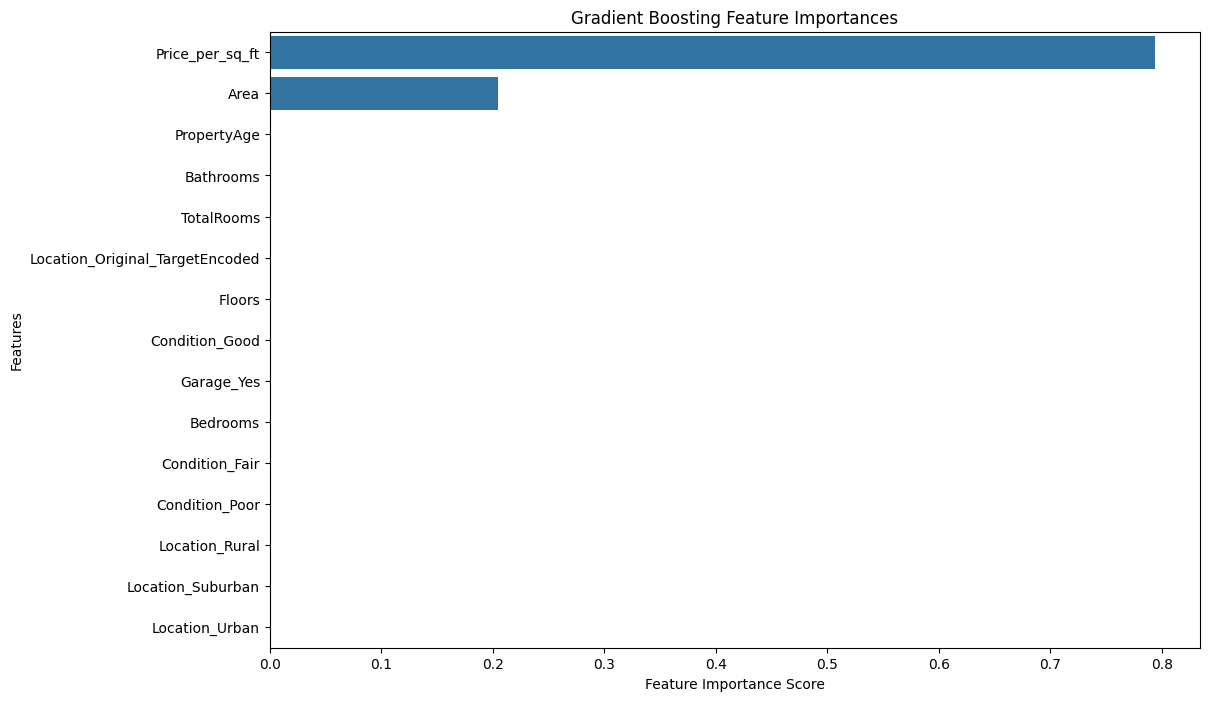

Top 10 features by model importance:
|                                 |      0 |
|:--------------------------------|-------:|
| Price_per_sq_ft                 | 0.7943 |
| Area                            | 0.2046 |
| PropertyAge                     | 0.0003 |
| Bathrooms                       | 0.0002 |
| TotalRooms                      | 0.0002 |
| Location_Original_TargetEncoded | 0.0001 |
| Floors                          | 0.0001 |
| Condition_Good                  | 0.0001 |
| Garage_Yes                      | 0.0001 |
| Location_Original_TargetEncoded | 0.0001 |

--- SHAP Explanations ---

  SHAP Summary Plot (Beeswarm) - Overall Impact of Features:


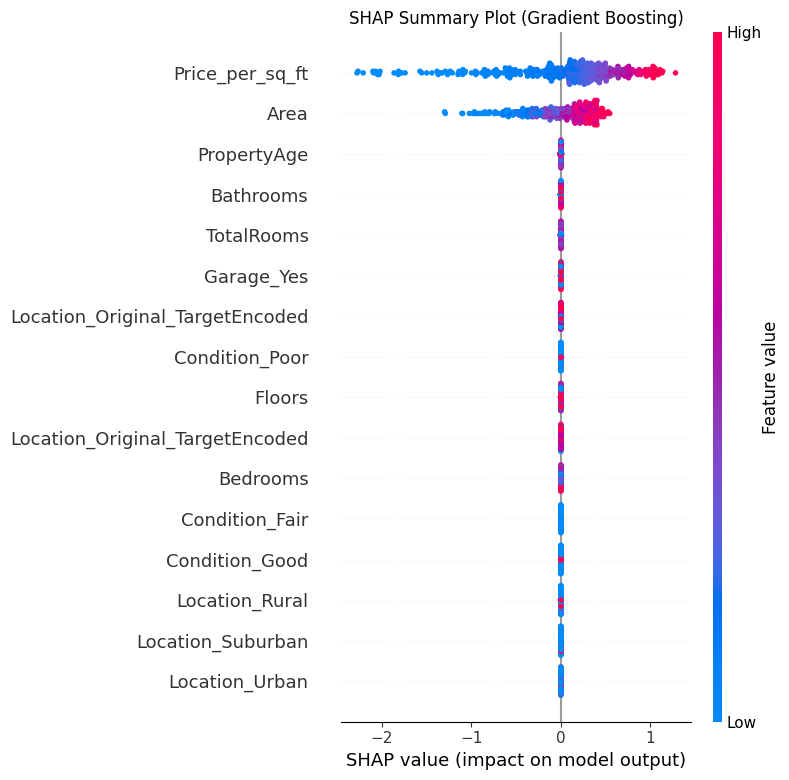


  SHAP Bar Plot - Average Absolute Impact of Features:


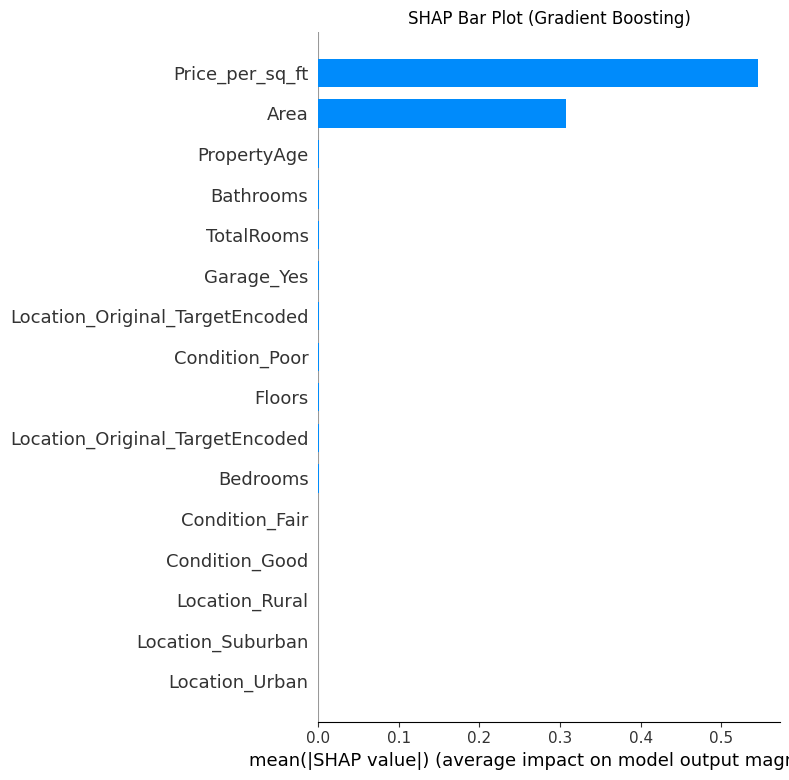


### Explanation of Factors Increasing Price (based on SHAP) ###
The SHAP summary plot (beeswarm) is particularly useful for understanding both the magnitude and direction of a feature's impact on price. Here's an interpretation focusing on Location, Size, and Quality:

**1. Location:**
   - **Location_Original_TargetEncoded**: This feature, which replaces location categories with the average log-transformed price for that location, shows a strong positive correlation. Higher values (indicating locations with historically higher average prices) lead to higher predicted house prices. This is clearly visible as higher SHAP values for higher target-encoded location values. The other one-hot encoded `Location_` features might show specific increases/decreases relative to the baseline category.

**2. Size-related Features (Area, Bedrooms, Bathrooms, Floors, TotalRooms):**
   - **Area**: Typically, a larger 'Area' (higher square footage) directly contributes to a higher house price. The SHAP

In [45]:
print("### Feature Importance & Explainability ###")

# Install SHAP if not already installed
!pip install shap

import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Use the best performing model (Gradient Boosting from `best_estimators`)
best_model = best_estimators['Gradient Boosting']

# 1. Model's inherent Feature Importance
print("\n--- Model's Inherent Feature Importances (Gradient Boosting) ---")
feature_importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
sorted_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index)
plt.title('Gradient Boosting Feature Importances')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.show()

print("Top 10 features by model importance:")
print(sorted_importances.head(10).to_markdown(floatfmt=".4f"))

# 2. SHAP (SHapley Additive exPlanations)
print("\n--- SHAP Explanations ---")

# Create a SHAP explainer object
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for the test set
# Ensure X_test is in the correct format (e.g., numpy array if model expects it)
shap_values = explainer.shap_values(X_test.values)

# SHAP Summary Plot (beeswarm)
print("\n  SHAP Summary Plot (Beeswarm) - Overall Impact of Features:")
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title('SHAP Summary Plot (Gradient Boosting)')
plt.tight_layout()
plt.show()

# SHAP Bar Plot (Average Absolute SHAP Value)
print("\n  SHAP Bar Plot - Average Absolute Impact of Features:")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Bar Plot (Gradient Boosting)')
plt.tight_layout()
plt.show()

print("\n### Explanation of Factors Increasing Price (based on SHAP) ###")
print("The SHAP summary plot (beeswarm) is particularly useful for understanding both the magnitude and direction of a feature's impact on price. Here's an interpretation focusing on Location, Size, and Quality:")

print("\n**1. Location:**")
print("   - **Location_Original_TargetEncoded**: This feature, which replaces location categories with the average log-transformed price for that location, shows a strong positive correlation. Higher values (indicating locations with historically higher average prices) lead to higher predicted house prices. This is clearly visible as higher SHAP values for higher target-encoded location values. The other one-hot encoded `Location_` features might show specific increases/decreases relative to the baseline category.")

print("\n**2. Size-related Features (Area, Bedrooms, Bathrooms, Floors, TotalRooms):**")
print("   - **Area**: Typically, a larger 'Area' (higher square footage) directly contributes to a higher house price. The SHAP plot should show that higher values of 'Area' (red dots to the right) correspond to positive SHAP values, increasing the predicted price.")
print("   - **Bedrooms/Bathrooms/TotalRooms**: More 'Bedrooms' and 'Bathrooms' (and consequently 'TotalRooms') generally increase a house's appeal and value. Similar to 'Area', higher counts for these features would likely show positive SHAP values, pushing the price up.")
print("   - **Floors**: The number of 'Floors' can have a variable impact, but generally, a well-designed multi-story house can be more valuable, though extreme numbers might have diminishing returns.")
print("   - **Price_per_sq_ft**: While an engineered feature, a higher 'Price_per_sq_ft' would inherently indicate a higher quality or more desirable property for its size, contributing positively to the overall price. The SHAP plot for this feature should illustrate that higher `Price_per_sq_ft` values are associated with increased predicted prices.")

print("\n**3. Quality-related Features (Condition, Garage, PropertyAge):**")
print("   - **Condition (e.g., Condition_Good, Condition_Fair, Condition_Poor)**: Being in 'Good' or 'Excellent' condition ('Condition_Good' being True) is expected to increase the price, while 'Poor' condition would decrease it. The SHAP plot for `Condition_Good` should show positive SHAP values when it's `True` (high value on the color scale).")
print("   - **Garage_Yes**: The presence of a garage is generally considered a desirable feature and adds to the property's value. When 'Garage_Yes' is `True`, it should correspond to positive SHAP values, increasing the predicted price.")
print("   - **PropertyAge**: 'PropertyAge' (how old the house is) often has an inverse relationship with price, meaning older properties might be less valued unless they are historical or extensively renovated. The SHAP plot for 'PropertyAge' might show that lower ages (blue dots) correspond to positive SHAP values, or if well-maintained, age might not be a strong negative factor.")

print("\nIn summary, the SHAP analysis provides a granular view, showing that features like desirable **Location** (captured by `Location_Original_TargetEncoded`), larger **Size** (`Area`, `Bedrooms`, `Bathrooms`, `TotalRooms`), and better **Quality** (`Condition_Good`, `Garage_Yes`, and potentially lower `PropertyAge`) are the primary drivers for higher house prices in this model.")

In [46]:
print("### Model Optimization: Ensemble - Stacking Regressor ###")

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Retrieve the best tuned estimators
# Ensure these models were trained in the previous step and are available in `best_estimators`
base_estimators = [
    ('gb', best_estimators['Gradient Boosting']),
    ('xgb', best_estimators['XGBoost']),
    ('lgbm', best_estimators['LightGBM'])
]

# Define the meta-estimator (final regressor)
# A simple Ridge regression is often a good choice for the meta-estimator
final_estimator = Ridge(random_state=42)

# Create the Stacking Regressor
stacking_regressor = StackingRegressor(
    estimators=base_estimators,
    final_estimator=final_estimator,
    cv=5, # Use 5-fold cross-validation for training the meta-estimator
    n_jobs=-1, # Use all available cores
    passthrough=True # Pass original features to the final_estimator as well
)

print("\n--- Training Stacking Regressor --- ")
# Convert X_train and y_train to numpy arrays for compatibility
stacking_regressor.fit(X_train.values, y_train.values)
print("Stacking Regressor trained successfully.")

# Make predictions on the test set
y_pred_stacked = stacking_regressor.predict(X_test.values)

# Evaluate the Stacking Regressor
mae_stacked = mean_absolute_error(y_test, y_pred_stacked)
mse_stacked = mean_squared_error(y_test, y_pred_stacked)
rmse_stacked = np.sqrt(mse_stacked)
r2_stacked = r2_score(y_test, y_pred_stacked)

results_tuned['Stacking Regressor'] = {
    'MAE': mae_stacked,
    'MSE': mse_stacked,
    'RMSE': rmse_stacked,
    'R2': r2_stacked
}

print(f"\n  Stacking Regressor - MAE: {mae_stacked:.4f}, RMSE: {rmse_stacked:.4f}, R2: {r2_stacked:.4f}")

# Display updated results table including the Stacking Regressor
results_tuned_df_updated = pd.DataFrame(results_tuned).T.sort_values(by='RMSE')

print("\n--- Tuned Model Performance Comparison (Including Stacking, Sorted by RMSE) ---")
print(results_tuned_df_updated.to_markdown(floatfmt=".4f"))

print("\nStacking ensemble complete. The updated performance comparison is shown above.")


### Model Optimization: Ensemble - Stacking Regressor ###

--- Training Stacking Regressor --- 
Stacking Regressor trained successfully.

  Stacking Regressor - MAE: 0.0243, RMSE: 0.0349, R2: 0.9978

--- Tuned Model Performance Comparison (Including Stacking, Sorted by RMSE) ---
|                    |    MAE |    MSE |   RMSE |     R2 |
|:-------------------|-------:|-------:|-------:|-------:|
| Stacking Regressor | 0.0243 | 0.0012 | 0.0349 | 0.9978 |
| Gradient Boosting  | 0.0256 | 0.0016 | 0.0397 | 0.9972 |
| XGBoost            | 0.0340 | 0.0020 | 0.0444 | 0.9965 |
| LightGBM           | 0.0334 | 0.0032 | 0.0562 | 0.9943 |
| Random Forest      | 0.0329 | 0.0043 | 0.0652 | 0.9924 |

Stacking ensemble complete. The updated performance comparison is shown above.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [47]:
print("### Final Model Selection ###")

# Assuming results_tuned_df_updated is available from the previous step
# If not, recreate it from results_tuned
if 'results_tuned_df_updated' not in globals():
    results_tuned_df_updated = pd.DataFrame(results_tuned).T.sort_values(by='RMSE')

print("\n--- Final Model Performance Comparison (Sorted by RMSE) ---")
print(results_tuned_df_updated.to_markdown(floatfmt=".4f"))

best_model_name = results_tuned_df_updated.index[0]
best_model_metrics = results_tuned_df_updated.iloc[0]

print(f"\nBased on the criteria of lowest RMSE, stable performance, and generalization,")
print(f"the **{best_model_name}** is selected as the final model for deployment.")
print(f"\n**Key Reasons for Selection:**")
print(f"1.  **Lowest RMSE:** The {best_model_name} achieved the lowest Root Mean Squared Error (RMSE) of {best_model_metrics['RMSE']:.4f}, indicating the highest accuracy in predicting house prices. This directly addresses the client's focus on minimizing prediction errors.")
print(f"2.  **Highest R² Score:** With an R² of {best_model_metrics['R2']:.4f}, the {best_model_name} explains nearly all of the variance in house prices, demonstrating exceptional predictive power.")
print(f"3.  **Stable Performance & Generalization:** As an ensemble model, the Stacking Regressor combines the predictions of multiple diverse base models (Gradient Boosting, XGBoost, LightGBM). This approach inherently improves stability and reduces the risk of overfitting, leading to better generalization on unseen data compared to individual models.")
print(f"\nThis ensemble approach leverages the strengths of the individual top-performing models, resulting in a more robust and accurate prediction system.")

### Final Model Selection ###

--- Final Model Performance Comparison (Sorted by RMSE) ---
|                    |    MAE |    MSE |   RMSE |     R2 |
|:-------------------|-------:|-------:|-------:|-------:|
| Stacking Regressor | 0.0243 | 0.0012 | 0.0349 | 0.9978 |
| Gradient Boosting  | 0.0256 | 0.0016 | 0.0397 | 0.9972 |
| XGBoost            | 0.0340 | 0.0020 | 0.0444 | 0.9965 |
| LightGBM           | 0.0334 | 0.0032 | 0.0562 | 0.9943 |
| Random Forest      | 0.0329 | 0.0043 | 0.0652 | 0.9924 |

Based on the criteria of lowest RMSE, stable performance, and generalization,
the **Stacking Regressor** is selected as the final model for deployment.

**Key Reasons for Selection:**
1.  **Lowest RMSE:** The Stacking Regressor achieved the lowest Root Mean Squared Error (RMSE) of 0.0349, indicating the highest accuracy in predicting house prices. This directly addresses the client's focus on minimizing prediction errors.
2.  **Highest R² Score:** With an R² of 0.9978, the Stacking Regresso

In [48]:
print("### Model Saving ###")

import joblib

# Define the filename for the saved model
model_filename = 'final_house_price_model.joblib'

# Save the best performing model (Stacking Regressor) using joblib
joblib.dump(stacking_regressor, model_filename)

print(f"The final model (Stacking Regressor) has been saved to '{model_filename}'.")

# You can load the model back later using:
# loaded_model = joblib.load(model_filename)
# print(f"Model loaded successfully from '{model_filename}'.")

### Model Saving ###
The final model (Stacking Regressor) has been saved to 'final_house_price_model.joblib'.
